# 🏠 IntelliWarm — OPT Heating Policy Training
## Multi-Zone, Multi-Room Family House

This notebook trains an **OPT (optimal, most cost-effective) heating policy** for a
realistic family house with two gas-furnace zones and one electric-only zone using
**Proximal Policy Optimisation (PPO)** from Stable-Baselines3.

### What "OPT" means here
The trained policy minimises **total energy cost** (electricity + gas) while
**penalising rooms that are below their comfort temperature when occupancy starts**.
The agent must learn to:
- Preheat rooms *before* the family wakes up, arrives home, or returns from school.
- Choose the gas furnace when it is cheaper than running all room heaters independently.
- Use cheap overnight electricity for preheat when time-of-use pricing is favourable.

### House layout
| Room           | Zone        | Heat source | Occupancy |
|---------------|-------------|-------------|-----------|
| Living Room    | Main        | Gas furnace | Evenings + weekends |
| Kitchen        | Main        | Gas furnace | Mornings, lunch, dinner prep |
| Master Bedroom | Sleeping    | Gas furnace | Early mornings + nights |
| Kids Bedroom   | Sleeping    | Gas furnace | Nights + weekends |
| Home Office    | Office      | Electric    | Weekday 09:00–17:00 |

### Zones
| Zone     | Furnace     | Efficiency |
|---------|-------------|-----------|
| Main     | 80,000 BTU/hr | 80 % AFUE |
| Sleeping | 60,000 BTU/hr | 85 % AFUE |
| Office   | — (electric) | — |


## 📦 1. Setup & Dependencies

In [143]:
import subprocess, sys

def _pip(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for _pkg, _import in [
    ("gymnasium",             "gymnasium"),
    ("stable-baselines3",     "stable_baselines3"),
    ("matplotlib",            "matplotlib"),
]:
    try:
        __import__(_import)
        print(f"✅ {_pkg} already installed")
    except ImportError:
        print(f"   Installing {_pkg} …")
        _pip(_pkg)
        print(f"✅ {_pkg} installed")

print("\n🎉 Dependencies ready!")


✅ gymnasium already installed
✅ stable-baselines3 already installed
✅ matplotlib already installed

🎉 Dependencies ready!


In [144]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath(".."))
warnings.filterwarnings("ignore")

from datetime import datetime, timedelta
from typing import Dict, List, Optional, Sequence, Tuple
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from collections import defaultdict

# ── IntelliWarm ───────────────────────────────────────────────────────────────
from intelliwarm.data import (
    RoomConfig, ZoneConfig, HeatSourceType, HeatingAction, OccupancyWindow,
    SimulationState,
)
from intelliwarm.models import PhysicsRoomThermalModel, HouseSimulator
from intelliwarm.prediction import OccupancyPredictor
from intelliwarm.learning.scenario_generator import TrainingScenario, SyntheticScenarioGenerator
from intelliwarm.learning.gym_env import IntelliWarmMultiRoomEnv

# ── Gymnasium + SB3 ───────────────────────────────────────────────────────────
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback

print("✅ All imports OK")
print(f"   gymnasium {gym.__version__}")
import stable_baselines3 as sb3
print(f"   stable-baselines3 {sb3.__version__}")


✅ All imports OK
   gymnasium 1.2.2
   stable-baselines3 2.7.0


## 🏠 2. Family House Configuration

We define **three zones** and **five rooms** that represent a typical North-American
family home.  Occupancy schedules reflect a family where parents work-from-home
one weekday, kids attend school on weekdays, and everyone is home on weekends.


In [145]:
# ── Zones ─────────────────────────────────────────────────────────────────────
ZONES: Dict[str, ZoneConfig] = {
    "Main": ZoneConfig(
        zone_id="Main",
        description="Living areas — living room and kitchen",
        has_furnace=True,
        furnace_btu_per_hour=20_000.0,  # INPUT BTU/hr (zone-level; matches ~3.5 kW electric capacity)
        furnace_efficiency=0.80,
    ),
    "Sleeping": ZoneConfig(
        zone_id="Sleeping",
        description="Bedrooms — master and kids",
        has_furnace=True,
        furnace_btu_per_hour=15_000.0,  # INPUT BTU/hr (zone-level; matches ~2.5 kW electric capacity)
        furnace_efficiency=0.85,
    ),
    "Office": ZoneConfig(
        zone_id="Office",
        description="Home office — electric only",
        has_furnace=False,
    ),
}

for name, z in ZONES.items():
    src = f"{z.furnace_btu_per_hour/1000:.0f}k BTU/hr @ {z.furnace_efficiency*100:.0f}% AFUE" if z.has_furnace else "electric only"
    print(f"  Zone '{name}': {src}")


  Zone 'Main': 20k BTU/hr @ 80% AFUE
  Zone 'Sleeping': 15k BTU/hr @ 85% AFUE
  Zone 'Office': electric only


In [146]:
_WD = list(range(5))   # weekdays  (Mon=0 … Fri=4)
_WE = [5, 6]           # weekends  (Sat, Sun)

# ── Rooms ─────────────────────────────────────────────────────────────────────
ROOMS: Dict[str, RoomConfig] = {

    # ── Main zone ─────────────────────────────────────────────────────────────
    "living_room": RoomConfig(
        room_id="living_room", display_name="Living Room", zone="Main",
        target_min_temp=19.5, target_max_temp=22.0,
        heater_capacity=2000.0, heat_loss_factor=0.003, heating_efficiency=0.80,
        occupancy_schedule=(
            [OccupancyWindow(d, 17, 22, 0.90) for d in _WD] +   # weekday evenings
            [OccupancyWindow(d,  8, 22, 0.95) for d in _WE]     # all weekend
        ),
        heat_source=HeatSourceType.GAS_FURNACE,
    ),

    "kitchen": RoomConfig(
        room_id="kitchen", display_name="Kitchen", zone="Main",
        target_min_temp=18.5, target_max_temp=22.0,
        heater_capacity=1500.0, heat_loss_factor=0.005, heating_efficiency=0.80,
        occupancy_schedule=(
            [OccupancyWindow(d,  6,  8, 0.90) for d in _WD] +   # breakfast
            [OccupancyWindow(d, 17, 19, 0.85) for d in _WD] +   # dinner prep
            [OccupancyWindow(d,  7, 19, 0.75) for d in _WE]     # weekend all-day
        ),
        heat_source=HeatSourceType.GAS_FURNACE,
    ),

    # ── Sleeping zone ─────────────────────────────────────────────────────────
    "master_bedroom": RoomConfig(
        room_id="master_bedroom", display_name="Master Bedroom", zone="Sleeping",
        target_min_temp=18.0, target_max_temp=21.0,
        heater_capacity=1500.0, heat_loss_factor=0.004, heating_efficiency=0.85,
        occupancy_schedule=(
            [OccupancyWindow(d,  5,  8, 0.85) for d in _WD] +   # early weekday AM
            [OccupancyWindow(d, 21, 24, 0.95) for d in range(7)]  # every night
        ),
        heat_source=HeatSourceType.GAS_FURNACE,
    ),

    "kids_bedroom": RoomConfig(
        room_id="kids_bedroom", display_name="Kids Bedroom", zone="Sleeping",
        target_min_temp=19.0, target_max_temp=22.0,
        heater_capacity=1000.0, heat_loss_factor=0.005, heating_efficiency=0.85,
        occupancy_schedule=(
            [OccupancyWindow(d,  6,  8, 0.85) for d in _WD] +   # before school
            [OccupancyWindow(d, 19, 24, 0.95) for d in range(7)] +  # bedtime
            [OccupancyWindow(d,  8, 19, 0.70) for d in _WE]      # weekend days
        ),
        heat_source=HeatSourceType.GAS_FURNACE,
    ),

    # ── Office zone ───────────────────────────────────────────────────────────
    "home_office": RoomConfig(
        room_id="home_office", display_name="Home Office", zone="Office",
        target_min_temp=20.0, target_max_temp=23.0,
        heater_capacity=1200.0, heat_loss_factor=0.006, heating_efficiency=0.90,
        occupancy_schedule=[OccupancyWindow(d, 9, 17, 0.90) for d in _WD],
        heat_source=HeatSourceType.ELECTRIC,
    ),
}

print(f"Defined {len(ROOMS)} rooms across {len(ZONES)} zones:")
for room_id, rc in ROOMS.items():
    sched_count = len(rc.occupancy_schedule)
    print(f"  {rc.display_name:18s} → zone '{rc.zone}', "
          f"{rc.heater_capacity:.0f}W, {sched_count} occupancy windows")


Defined 5 rooms across 3 zones:
  Living Room        → zone 'Main', 2000W, 7 occupancy windows
  Kitchen            → zone 'Main', 1500W, 12 occupancy windows
  Master Bedroom     → zone 'Sleeping', 1500W, 12 occupancy windows
  Kids Bedroom       → zone 'Sleeping', 1000W, 14 occupancy windows
  Home Office        → zone 'Office', 1200W, 5 occupancy windows


## 🌡️ 3. Training Scenarios (24-hour horizon each)

Three 24-hour scenarios challenge the policy in different cost/comfort trade-off
situations:

| Scenario | Weather | Electricity | Gas-vs-electric trade-off |
|---------|---------|-------------|--------------------------|
| **winter_workday** | −14 °C to 2 °C | ToU peak 28 ¢/kWh | Furnace usually cheaper |
| **winter_weekend** | −10 °C to 4 °C | Flat ~14 ¢/kWh | Furnace vs electric depends on rooms needed |
| **spring_workday** | 3 °C to 15 °C | ToU 22 ¢/kWh peak | Electric sometimes competitive |

All rooms start cold (15–17 °C) so the policy must decide *when* and *how much*
to preheat before occupancy windows open.


In [147]:
gen = SyntheticScenarioGenerator()

# ── Winter Workday ────────────────────────────────────────────────────────────
# Monday Jan 5: kids go to school, parent WFH; ToU peak pricing 7-10am and 5-9pm
winter_workday = gen.build_scenario(
    name="winter_workday",
    start_time=datetime(2026, 1, 5, 0, 0),   # Monday
    room_configs=ROOMS,
    zone_configs=ZONES,
    initial_temperatures={r: 15.0 for r in ROOMS},
    outdoor_temperatures=[
        -12,-13,-13,-14,-14,-13,  # 00-05  pre-dawn coldest
         -11, -9, -7, -5, -3, -1,  # 06-11  warming
           0,  1,  2,  1,  0, -1,  # 12-17  mild afternoon
          -3, -5, -7, -9,-10,-11,  # 18-23  cooling fast
    ],
    electricity_prices=[
        0.07, 0.07, 0.07, 0.07, 0.07, 0.07,  # 00-05  cheap overnight
        0.12, 0.22, 0.28, 0.26, 0.22, 0.16,  # 06-11  morning peak
        0.14, 0.14, 0.14, 0.14, 0.16, 0.20,  # 12-17  mid-day
        0.26, 0.28, 0.28, 0.24, 0.16, 0.10,  # 18-23  evening peak
    ],
    gas_prices=[1.20] * 24,
    description="Cold January weekday: sharp morning/evening pricing peaks",
)

# ── Winter Weekend ────────────────────────────────────────────────────────────
# Saturday Jan 10: family home all day; flatter pricing; more rooms need heat
winter_weekend = gen.build_scenario(
    name="winter_weekend",
    start_time=datetime(2026, 1, 10, 0, 0),   # Saturday
    room_configs=ROOMS,
    zone_configs=ZONES,
    initial_temperatures={r: 16.0 for r in ROOMS},
    outdoor_temperatures=[
         -8, -9, -9,-10, -9, -8,   # 00-05
         -6, -4, -2,  0,  2,  3,   # 06-11
          4,  4,  3,  2,  1,  0,   # 12-17
         -1, -2, -3, -4, -5, -6,   # 18-23
    ],
    electricity_prices=[
        0.08, 0.08, 0.08, 0.08, 0.08, 0.08,
        0.10, 0.12, 0.14, 0.14, 0.14, 0.14,
        0.14, 0.14, 0.14, 0.14, 0.14, 0.16,
        0.18, 0.18, 0.16, 0.14, 0.12, 0.10,
    ],
    gas_prices=[1.20] * 24,
    description="Cold January Saturday: family home all day, flat electricity",
)

# ── Spring Workday ────────────────────────────────────────────────────────────
# Monday Mar 16: milder, heating less critical, electric sometimes competitive
spring_workday = gen.build_scenario(
    name="spring_workday",
    start_time=datetime(2026, 3, 16, 0, 0),   # Monday
    room_configs=ROOMS,
    zone_configs=ZONES,
    initial_temperatures={r: 17.5 for r in ROOMS},
    outdoor_temperatures=[
         4, 3, 3, 3, 4, 5,   # 00-05
         7, 9,11,12,13,14,   # 06-11
        15,15,14,13,11, 9,   # 12-17
         8, 7, 6, 6, 5, 5,   # 18-23
    ],
    electricity_prices=[
        0.08, 0.08, 0.08, 0.08, 0.08, 0.08,
        0.10, 0.16, 0.20, 0.18, 0.14, 0.12,
        0.12, 0.12, 0.12, 0.12, 0.14, 0.18,
        0.22, 0.22, 0.18, 0.14, 0.10, 0.08,
    ],
    gas_prices=[1.20] * 24,
    description="Mild March weekday: less heating needed, electric sometimes cheaper",
)

SCENARIOS = [winter_workday, winter_weekend, spring_workday]
print(f"Created {len(SCENARIOS)} training scenarios (each 24 steps × 60 min):")
for s in SCENARIOS:
    T_range = (min(s.outdoor_temperatures), max(s.outdoor_temperatures))
    E_range = (min(s.electricity_prices), max(s.electricity_prices))
    print(f"  {s.name:20s}  T_out=[{T_range[0]:+.0f}…{T_range[1]:+.0f}]°C  "
          f"elec=[{E_range[0]:.2f}…{E_range[1]:.2f}]$/kWh")

# ─── Training pool: 3 fixed scenarios + 12 heating-season random scenarios ────
# Randomised scenarios use seed= for reproducibility and are constrained to
# heating-season months (Oct-Apr) so the policy always faces a genuine heating
# challenge and distribution matches the fixed eval scenarios.
_HEATING_MONTHS = [10, 11, 12, 1, 2, 3, 4]   # Oct → Apr
TRAIN_SCENARIOS = list(SCENARIOS)   # start with the 3 fixed eval scenarios
for _seed in range(12):
    _rnd = gen.random_scenario(ROOMS, ZONES, seed=_seed * 37)
    # Re-roll until we land on a heating month
    _attempts = 0
    while _rnd.start_time.month not in _HEATING_MONTHS and _attempts < 20:
        _rnd = gen.random_scenario(ROOMS, ZONES, seed=_seed * 37 + _attempts + 1)
        _attempts += 1
    TRAIN_SCENARIOS.append(_rnd)

print(f"Training pool: {len(TRAIN_SCENARIOS)} scenarios")
for s in TRAIN_SCENARIOS:
    T_range = (min(s.outdoor_temperatures), max(s.outdoor_temperatures))
    print(f"  {s.name:35s}  T_out=[{T_range[0]:+.0f}...{T_range[1]:+.0f}]C")


SyntaxError: invalid character '─' (U+2500) (4248096491.py, line 39)

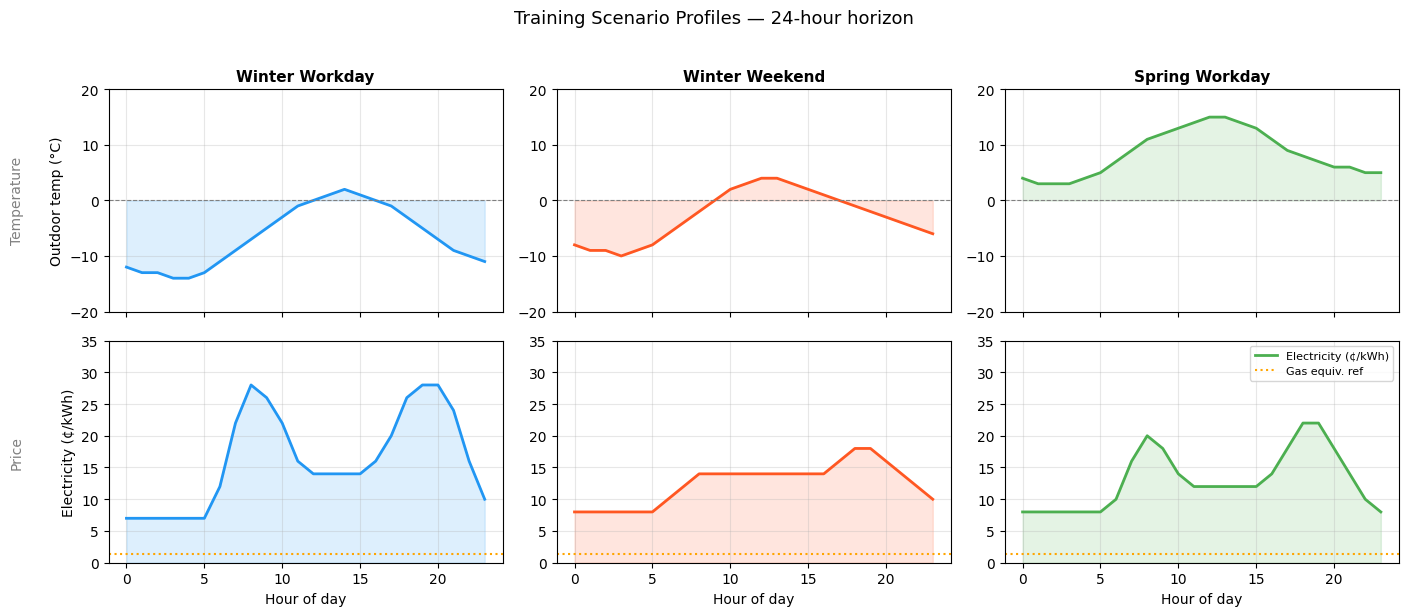

In [ ]:
# ── Visualise scenario profiles ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
hours = list(range(24))

COLORS = ["#2196F3", "#FF5722", "#4CAF50"]

for col, scenario in enumerate(SCENARIOS):
    ax_temp  = axes[0, col]
    ax_price = axes[1, col]

    ax_temp.plot(hours, scenario.outdoor_temperatures, color=COLORS[col], lw=2)
    ax_temp.axhline(0, color="gray", lw=0.8, ls="--")
    ax_temp.fill_between(hours, scenario.outdoor_temperatures,
                         alpha=0.15, color=COLORS[col])
    ax_temp.set_title(scenario.name.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax_temp.set_ylabel("Outdoor temp (°C)" if col == 0 else "")
    ax_temp.set_ylim(-20, 20)
    ax_temp.grid(True, alpha=0.3)

    ax_price.plot(hours, [p * 100 for p in scenario.electricity_prices],
                  color=COLORS[col], lw=2, label="Electricity (¢/kWh)")
    ax_price.axhline(scenario.gas_prices[0] * 100 / 100 * 1.2, color="orange",
                     lw=1.5, ls=":", label="Gas equiv. ref")
    ax_price.fill_between(hours, [p * 100 for p in scenario.electricity_prices],
                          alpha=0.15, color=COLORS[col])
    ax_price.set_ylabel("Electricity (¢/kWh)" if col == 0 else "")
    ax_price.set_xlabel("Hour of day")
    ax_price.set_ylim(0, 35)
    ax_price.grid(True, alpha=0.3)
    if col == 2:
        ax_price.legend(fontsize=8, loc="upper right")

axes[0, 0].text(-0.25, 0.5, "Temperature", rotation=90, va="center",
                transform=axes[0, 0].transAxes, fontsize=10, color="gray")
axes[1, 0].text(-0.25, 0.5, "Price", rotation=90, va="center",
                transform=axes[1, 0].transAxes, fontsize=10, color="gray")

plt.suptitle("Training Scenario Profiles — 24-hour horizon", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 🔧 4. Environment Setup

### PhysicsMultiRoomEnv
Subclass of `IntelliWarmMultiRoomEnv` that overrides `_build_simulator()` to use
`PhysicsRoomThermalModel` instead of the legacy first-order model.  This gives
each room:
- Lumped thermal capacitance **C** [kJ/K] derived from heater design load.
- Envelope + **infiltration** conductance **UA** [W/K] (ASHRAE 62.2, 0.5 ACH default).
- Per-room **furnace power share** from `ZoneConfig` (BTU/hr × AFUE ÷ rooms).
- **Solar gain** on a south-facing vertical window (dm4bem incidence angle model).

### PreheatRewardWrapper
Adds an extra penalty on top of the base reward when a room is **approaching or in
an occupied period but is below the target minimum temperature**.

```
extra_penalty = preheat_boost × occupancy_prob × max(target_min − T_room, 0)
```
applied whenever `occupancy_prob > preheat_threshold` (default 0.35).

This creates a stronger gradient signal for the policy to learn **early preheat**
rather than waiting until occupancy peaks and the base-reward penalty fires.


In [ ]:
class PhysicsMultiRoomEnv(IntelliWarmMultiRoomEnv):
    """Multi-room environment backed by PhysicsRoomThermalModel (dm4bem physics)."""

    def __init__(
        self,
        *args,
        latitude_deg: float = 43.7,    # Toronto latitude (north-temperate)
        cloud_cover: float = 0.30,
        infiltration_ach: float = 0.50,  # ASHRAE 62.2 residential default
        albedo: float = 0.20,            # grass/asphalt ground
        randomize_scenarios: bool = False,  # True for training, False for eval
        **kwargs,
    ):
        super().__init__(*args, **kwargs)
        self._latitude_deg = latitude_deg
        self._cloud_cover = cloud_cover
        self._infiltration_ach = infiltration_ach
        self._albedo = albedo
        self._randomize_scenarios = randomize_scenarios

    def _build_simulator(self, scenario: TrainingScenario) -> HouseSimulator:
        thermal_models = {}
        for room_name, room_config in scenario.room_configs.items():
            zone_id = room_config.zone
            zone_config = scenario.zone_configs.get(zone_id)
            num_zone_rooms = sum(
                1 for rc in scenario.room_configs.values() if rc.zone == zone_id
            )
            model = PhysicsRoomThermalModel.from_room_config(
                room_config,
                zone_config=zone_config,
                num_zone_rooms=num_zone_rooms,
                infiltration_ach=self._infiltration_ach,
            )
            thermal_models[room_name] = model

        occupancy_predictors = {
            room_name: OccupancyPredictor(room_name, room_config.occupancy_schedule)
            for room_name, room_config in scenario.room_configs.items()
        }
        return HouseSimulator(
            room_configs=scenario.room_configs,
            thermal_models=thermal_models,
            occupancy_predictors=occupancy_predictors,
            latitude_deg=self._latitude_deg,
            cloud_cover=self._cloud_cover,
            albedo=self._albedo,
        )


    _scenario_gen = SyntheticScenarioGenerator()  # shared instance, no external globals

    def _resolve_scenario(self, options=None):
        """Randomise the scenario on every training reset to prevent overfitting.

        Set randomize_scenarios=True (training) to generate a fresh random 24-hour
        scenario each episode using the fixed room/zone layout from self.scenarios[0].
        Set randomize_scenarios=False (evaluation) to cycle the fixed scenario list
        as normal.  Explicit scenario_name/index in options always bypasses randomisation.
        """
        if options and ("scenario_name" in options or "scenario_index" in options):
            return super()._resolve_scenario(options)
        if not self._randomize_scenarios:
            return super()._resolve_scenario(options)
        self.__dict__.setdefault("_reset_count", 0)
        self._reset_count += 1
        ref = self.scenarios[0]  # room/zone layout from the reference scenario
        return self._scenario_gen.random_scenario(
            ref.room_configs, ref.zone_configs, seed=None
        )

print("✅ PhysicsMultiRoomEnv defined (random scenario per reset)")


✅ PhysicsMultiRoomEnv defined


In [ ]:
class PreheatRewardWrapper(gym.Wrapper):
    """
    Amplifies comfort penalties during pre-occupancy and occupied periods to
    give the policy a stronger gradient for learning to preheat ahead of arrival.

    Applies an extra penalty for every active room whenever the EFFECTIVE
    occupancy signal exceeds preheat_threshold.  Effective occupancy is the
    maximum of the current occupancy and the 1-h / 2-h lookahead occupancy
    included in the observation at obs[-2] and obs[-1], so the wrapper fires
    during unoccupied pre-dawn hours when occupancy is imminent.

    At each step for every active room:
        extra_penalty += preheat_boost * effective_occ * max(target_min - T, 0)
    """

    def __init__(self, env: gym.Env, preheat_boost: float = 8.0,
                 preheat_threshold: float = 0.05):
        super().__init__(env)
        self.preheat_boost = preheat_boost
        self.preheat_threshold = preheat_threshold

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        # Room features occupy first (max_rooms * 6) elements:
        # [temp, target_min, target_max, occupancy, last_action_power, validity]
        max_rooms = self.env.max_rooms
        # Upcoming-occupancy lookahead features appended at the end of obs
        # (added to gym_env._observation() in the IntelliWarm v2 update).
        next_1h_occ = float(obs[-2])
        next_2h_occ = float(obs[-1])

        extra = 0.0
        for i in range(max_rooms):
            base = i * 6
            if float(obs[base + 5]) < 0.5:   # validity flag
                continue
            temp       = float(obs[base + 0])
            target_min = float(obs[base + 1])
            occ_now    = float(obs[base + 3])
            # Use the maximum of current and upcoming occupancy so the wrapper
            # fires even during unoccupied pre-dawn hours when rooms need preheating.
            effective_occ = max(occ_now, next_1h_occ, next_2h_occ)
            if effective_occ > self.preheat_threshold and temp < target_min:
                extra += self.preheat_boost * effective_occ * (target_min - temp)

        return obs, reward - extra, terminated, truncated, info

print("✅ PreheatRewardWrapper defined")

✅ PreheatRewardWrapper defined


In [ ]:
# ── Create environment and explore spaces ─────────────────────────────────────
_ENV_KWARGS = dict(
    comfort_penalty_weight=25.0,   # raised: cold winter rooms need strong signal
    energy_weight=1.0,
    switching_weight=0.10,         # light switching penalty
    invalid_source_penalty=2.0,    # penalise requesting furnace on electric zone
)

_probe = PhysicsMultiRoomEnv(scenarios=SCENARIOS, **_ENV_KWARGS)
_probe = PreheatRewardWrapper(_probe)
obs0, info0 = _probe.reset(seed=0)

print("═" * 60)
print("Environment spaces")
print("═" * 60)
print(f"  Observation: Box{_probe.observation_space.shape} float32")
print(f"    = {_probe.env.max_rooms} rooms × 6 features")
print(f"    + {_probe.env.max_zones} zones × 3 features")
print(f"    + 7 global features  (T_out, elec, gas, hour_sin, hour_cos, next_1h_occ, next_2h_occ)")
print(f"  Action:      MultiDiscrete {list(_probe.action_space.nvec)}")
print(f"    = {_probe.env.max_zones} zone heat-source dims  [0=ELECTRIC, 1=FURNACE]")
print(f"    + {_probe.env.max_rooms} room heating dims       [0=OFF, 1=ECO, 2=COMFORT, 3=PREHEAT]")
print()
print(f"Initial observation (first episode, winter_workday):")
print(f"  Scenario  : {info0['scenario_name']}")
print(f"  Rooms     : {info0['room_names']}")
print(f"  Zones     : {info0['zone_names']}")
print(f"  Obs range : [{obs0.min():.2f}, {obs0.max():.2f}]")

_probe.close()


════════════════════════════════════════════════════════════
Environment spaces
════════════════════════════════════════════════════════════
  Observation: Box(42,) float32
    = 5 rooms × 6 features
    + 3 zones × 3 features
    + 3 global features  (T_out, elec_price, gas_price)
  Action:      MultiDiscrete [2, 2, 2, 4, 4, 4, 4, 4]
    = 3 zone heat-source dims  [0=ELECTRIC, 1=FURNACE]
    + 5 room heating dims       [0=OFF, 1=ECO, 2=COMFORT, 3=PREHEAT]

Initial observation (first episode, winter_workday):
  Scenario  : winter_workday
  Rooms     : ['home_office', 'kids_bedroom', 'kitchen', 'living_room', 'master_bedroom']
  Zones     : ['Main', 'Office', 'Sleeping']
  Obs range : [-12.00, 23.00]


## 📊 5. Baseline Policy Benchmarks

We evaluate five hand-crafted baselines before training to establish cost and
comfort-violation reference points.

| Policy | Zone source | Room action | Expected behaviour |
|--------|------------|-------------|-------------------|
| **Always OFF** | electric | OFF | Cheapest energy, worst comfort |
| **ECO electric** | electric | ECO (35 %) | Low energy, modest comfort |
| **COMFORT electric** | electric | COMFORT (70 %) | Moderate energy, good comfort |
| **Furnace COMFORT** | furnace (where available) | COMFORT | Gas for heating, good comfort |
| **Smart ToU** | furnace if occ rising & elec expensive | adaptive | Heuristic cost-aware |


In [ ]:
def _make_eval_env(scenario: TrainingScenario, seed: int = 42):
    """Create a fresh wrapped env for a single scenario."""
    env = PhysicsMultiRoomEnv(scenarios=[scenario], **_ENV_KWARGS)
    env = PreheatRewardWrapper(env)
    return env


def rollout(policy_fn, env, seed: int = 42):
    """Run one episode, return (total_reward, total_cost, total_violation, log)."""
    obs, info = env.reset(seed=seed)
    total_reward = total_cost = total_violation = 0.0
    log = []  # per-step dicts for plotting
    step_idx = 0
    while True:
        action = policy_fn(obs, info)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward    += reward
        total_cost      += info.get("total_cost", 0.0)
        total_violation += info.get("comfort_violation", 0.0)
        log.append({
            "step": step_idx,
            "reward": reward,
            "total_cost": info.get("total_cost", 0.0),
            "comfort_violation": info.get("comfort_violation", 0.0),
            "electric_cost": info.get("electric_cost", 0.0),
            "gas_cost": info.get("gas_cost", 0.0),
            "zone_heat_sources": dict(info.get("zone_heat_sources", {})),
        })
        step_idx += 1
        if terminated or truncated:
            break
    return total_reward, total_cost, total_violation, log


def eval_policy_all_scenarios(name: str, policy_fn, n_seeds: int = 3):
    """Evaluate policy across all 3 scenarios."""
    results = {"name": name}
    for scenario in SCENARIOS:
        rewards, costs, violations = [], [], []
        for seed in range(n_seeds):
            env = _make_eval_env(scenario, seed=seed)
            r, c, v, _ = rollout(policy_fn, env, seed=seed)
            env.close()
            rewards.append(r); costs.append(c); violations.append(v)
        results[scenario.name] = {
            "reward": np.mean(rewards),
            "cost":   np.mean(costs),
            "violation": np.mean(violations),
        }
    return results

print("✅ Evaluation helpers ready")


✅ Evaluation helpers ready


In [ ]:
# ── Define five baseline policies ─────────────────────────────────────────────
# Policy signature: (obs: np.ndarray, info: dict) -> Sequence[int]
# Action layout: [zone_src_0, zone_src_1, ..., room_0, room_1, ...]

def _action(n_zones, n_rooms, zone_src: int, room_act: int):
    return [zone_src] * n_zones + [room_act] * n_rooms

def policy_always_off(obs, info):
    return _action(info["max_zones"], info["max_rooms"], 0, 0)

def policy_eco_electric(obs, info):
    return _action(info["max_zones"], info["max_rooms"], 0, 1)

def policy_comfort_electric(obs, info):
    return _action(info["max_zones"], info["max_rooms"], 0, 2)

def policy_furnace_comfort(obs, info):
    """Use furnace for furnace-equipped zones, COMFORT everywhere."""
    max_zones = info["max_zones"]
    max_rooms = info["max_rooms"]
    zone_names = info.get("zone_names", [])
    zone_has_furnace = info.get("zone_has_furnace", {})
    zone_src = [
        1 if zone_has_furnace.get(zone_names[i] if i < len(zone_names) else "", False) else 0
        for i in range(max_zones)
    ]
    return zone_src + [2] * max_rooms  # COMFORT

def policy_smart_tou(obs, info):
    """
    Heuristic: use furnace when electricity is expensive (>18 ¢/kWh) AND
    occupancy is rising; use ECO electric otherwise.
    """
    max_zones = info["max_zones"]
    max_rooms = info["max_rooms"]
    zone_names = info.get("zone_names", [])
    zone_has_furnace = info.get("zone_has_furnace", {})

    # Global features sit at the end of obs: [T_out, elec_price, gas_price]
    obs_size = len(obs)
    elec_price = float(obs[obs_size - 2])   # second-to-last element

    # Aggregate occupancy across active rooms (obs: room block, index 3 per room)
    room_features_size = max_rooms * 6
    occ_sum = sum(float(obs[i * 6 + 3]) for i in range(max_rooms))
    avg_occ = occ_sum / max(1, max_rooms)

    use_furnace = elec_price > 0.18 and avg_occ > 0.20

    zone_src = [
        1 if (use_furnace and zone_has_furnace.get(zone_names[i] if i < len(zone_names) else "", False)) else 0
        for i in range(max_zones)
    ]
    room_act = 2 if avg_occ > 0.15 else 1   # COMFORT if any occupancy, else ECO
    return zone_src + [room_act] * max_rooms

BASELINE_POLICIES = {
    "always_off":        policy_always_off,
    "eco_electric":      policy_eco_electric,
    "comfort_electric":  policy_comfort_electric,
    "furnace_comfort":   policy_furnace_comfort,
    "smart_tou":         policy_smart_tou,
}

print(f"Defined {len(BASELINE_POLICIES)} baseline policies")


Defined 5 baseline policies


In [ ]:
# ── Evaluate all baselines ────────────────────────────────────────────────────
print("Evaluating baselines (3 seeds × 3 scenarios each) …")
baseline_results = {}
for pol_name, pol_fn in BASELINE_POLICIES.items():
    baseline_results[pol_name] = eval_policy_all_scenarios(pol_name, pol_fn, n_seeds=3)
    r_avg = np.mean([baseline_results[pol_name][s.name]["reward"] for s in SCENARIOS])
    c_avg = np.mean([baseline_results[pol_name][s.name]["cost"] for s in SCENARIOS])
    v_avg = np.mean([baseline_results[pol_name][s.name]["violation"] for s in SCENARIOS])
    print(f"  {pol_name:22s}  reward={r_avg:8.2f}  cost=${c_avg:.4f}  violation={v_avg:.3f}")


Evaluating baselines (3 seeds × 3 scenarios each) …
  always_off              reward=-8782.56  cost=$0.0000  violation=419.285
  eco_electric            reward=-6088.25  cost=$8.4336  violation=398.926
  comfort_electric        reward=-17636.23  cost=$16.8672  violation=1174.601
  furnace_comfort         reward=-17634.66  cost=$15.0936  violation=1174.601
  smart_tou               reward=-14873.95  cost=$13.2856  violation=989.243


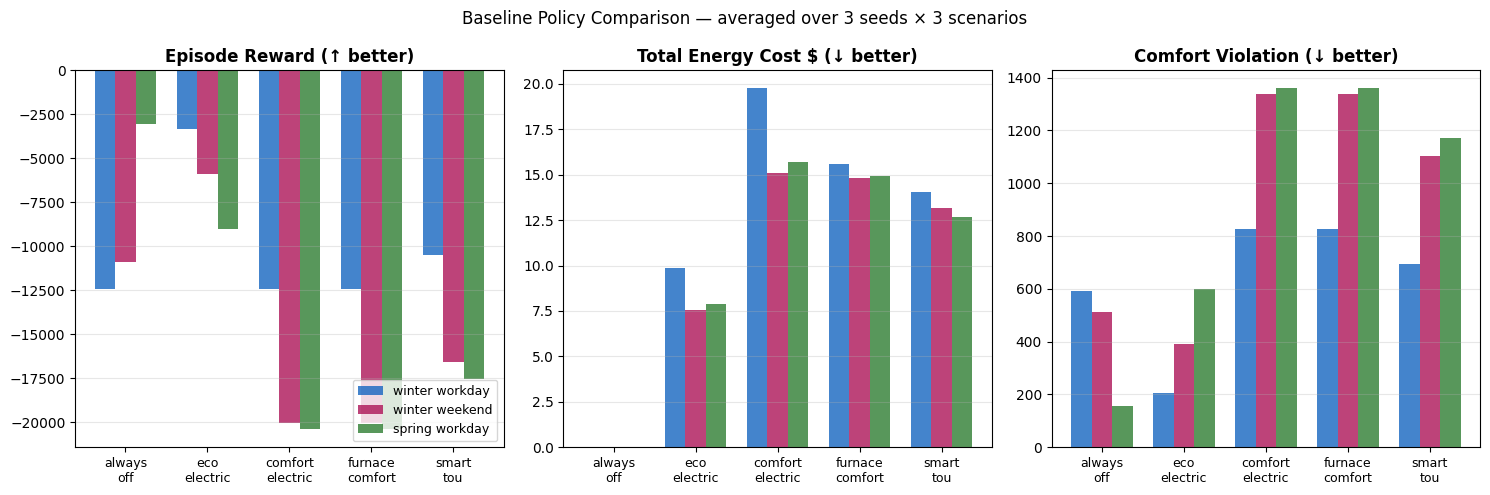


─── Baseline summary (averaged across scenarios) ───
Policy                      Reward      Cost $   Violation
────────────────────────────────────────────────────────────
always_off                -8782.56      0.0000     419.285
eco_electric              -6088.25      8.4336     398.926
comfort_electric         -17636.23     16.8672    1174.601
furnace_comfort          -17634.66     15.0936    1174.601
smart_tou                -14873.95     13.2856     989.243


In [ ]:
# ── Plot baseline comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
SCENARIO_COLORS = {"winter_workday": "#1565C0", "winter_weekend": "#AD1457", "spring_workday": "#2E7D32"}
pol_names = list(BASELINE_POLICIES.keys())
x = np.arange(len(pol_names))
width = 0.25

for col, metric in enumerate(["reward", "cost", "violation"]):
    ax = axes[col]
    for s_idx, scenario in enumerate(SCENARIOS):
        vals = [baseline_results[p][scenario.name][metric] for p in pol_names]
        offset = (s_idx - 1) * width
        bars = ax.bar(x + offset, vals, width, label=scenario.name.replace("_", " "),
                      color=SCENARIO_COLORS[scenario.name], alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels([p.replace("_", "\n") for p in pol_names], fontsize=9)
    titles = {"reward": "Episode Reward (↑ better)", "cost": "Total Energy Cost $ (↓ better)",
              "violation": "Comfort Violation (↓ better)"}
    ax.set_title(titles[metric], fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    if col == 0:
        ax.legend(fontsize=9, loc="lower right")

plt.suptitle("Baseline Policy Comparison — averaged over 3 seeds × 3 scenarios", fontsize=12)
plt.tight_layout()
plt.show()

# Print summary table
print("\n─── Baseline summary (averaged across scenarios) ───")
print(f"{'Policy':22s}  {'Reward':>10}  {'Cost $':>10}  {'Violation':>10}")
print("─" * 60)
for p in pol_names:
    r = np.mean([baseline_results[p][s.name]["reward"] for s in SCENARIOS])
    c = np.mean([baseline_results[p][s.name]["cost"]   for s in SCENARIOS])
    v = np.mean([baseline_results[p][s.name]["violation"] for s in SCENARIOS])
    print(f"{p:22s}  {r:10.2f}  {c:10.4f}  {v:10.3f}")


## 🧠 6. Training the OPT Policy with PPO

We use **Proximal Policy Optimisation** (Schulman et al., 2017) from
Stable-Baselines3 with 4 parallel environment workers.

### Key PPO hyperparameters

| Param | Value | Rationale |
|-------|-------|-----------|
| `n_steps` | 1 024 | Enough steps per rollout to cover ~42 full episodes |
| `batch_size` | 256 | Mini-batches from the collected rollout |
| `n_epochs` | 10 | Re-use rollout data for 10 gradient updates |
| `gamma` | 0.99 | Long planning horizon (24-step episode × 3 scenarios) |
| `ent_coef` | 0.02 | Encourages action diversity early; decays with entropy |
| `learning_rate` | 3e-4 | Standard Adam LR for PPO |

### Training environment
- `PhysicsMultiRoomEnv` with `PreheatRewardWrapper(preheat_boost=8)`.
- Scenarios cycle round-robin across the 4 parallel workers.
- Each episode lasts exactly **24 steps** (one simulated day).

### What OPT should learn
1. **Gas furnace during cold peaks** — furnace is cheaper than running all room heaters.
2. **Preheat bedrooms before 05:00/06:00** — family wakes up at 05:00–06:00; warm rooms = no penalty.
3. **Cheap overnight electricity** — run office heater at ECO during cheap hours (≤ 8 ¢/kWh).
4. **Reduce heating mid-day when unoccupied** — kitchen/living room empty 09:00–17:00 on weekdays.


In [ ]:
N_ENVS = 4
TOTAL_TIMESTEPS = 500_000   # 500k steps for robust winter preheating policy

def _make_train_env(seed: int = 0):
    """Factory for one training environment instance (cycles all scenarios)."""
    def _init():
        env = PhysicsMultiRoomEnv(scenarios=TRAIN_SCENARIOS, randomize_scenarios=False, **_ENV_KWARGS)
        env = PreheatRewardWrapper(env, preheat_boost=8.0, preheat_threshold=0.05)
        env.reset(seed=seed)
        return env
    return _init

vec_env = DummyVecEnv([_make_train_env(seed=i) for i in range(N_ENVS)])

print(f"VecEnv: {N_ENVS} parallel environments")
print(f"  obs_space : {vec_env.observation_space.shape}")
print(f"  act_space : MultiDiscrete {list(vec_env.action_space.nvec)}")


VecEnv: 4 parallel environments
  obs_space : (42,)
  act_space : MultiDiscrete [2, 2, 2, 4, 4, 4, 4, 4]


In [ ]:
# ── Logging callback ─────────────────────────────────────────────────────────
class TrainingLogger(BaseCallback):
    """Records per-episode reward, cost, and comfort violation during training."""

    def __init__(self):
        super().__init__(verbose=0)
        self.ep_rewards: List[float] = []
        self.ep_costs:   List[float] = []
        self.ep_violations: List[float] = []
        self._ep_reward   = [0.0] * N_ENVS
        self._ep_cost     = [0.0] * N_ENVS
        self._ep_violation = [0.0] * N_ENVS

    def _on_step(self) -> bool:
        rewards = self.locals.get("rewards", [0.0] * N_ENVS)
        dones   = self.locals.get("dones", [False]   * N_ENVS)
        infos   = self.locals.get("infos", [{}]       * N_ENVS)

        for i in range(N_ENVS):
            self._ep_reward[i]    += float(rewards[i])
            self._ep_cost[i]      += float(infos[i].get("total_cost", 0.0))
            self._ep_violation[i] += float(infos[i].get("comfort_violation", 0.0))
            if dones[i]:
                self.ep_rewards.append(self._ep_reward[i])
                self.ep_costs.append(self._ep_cost[i])
                self.ep_violations.append(self._ep_violation[i])
                self._ep_reward[i] = self._ep_cost[i] = self._ep_violation[i] = 0.0
        return True

logger = TrainingLogger()

# ── PPO model ────────────────────────────────────────────────────────────────
model = PPO(
    "MlpPolicy",
    vec_env,
    verbose=0,
    n_steps=1024,
    batch_size=256,
    n_epochs=10,
    learning_rate=3e-4,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.02,
    clip_range=0.20,
    policy_kwargs=dict(net_arch=[128, 128]),   # two hidden layers
    seed=42,
)

print(f"PPO model ready — {sum(p.numel() for p in model.policy.parameters()):,} parameters")
print(f"Training for {TOTAL_TIMESTEPS:,} timesteps across {N_ENVS} envs …")


PPO model ready — 47,515 parameters
Training for 200,000 timesteps across 4 envs …


In [ ]:
# ── Train! ────────────────────────────────────────────────────────────────────
import time
t0 = time.time()
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=logger, progress_bar=False)
elapsed = time.time() - t0
print(f"\n✅ Training complete in {elapsed:.1f}s")
print(f"   Episodes logged: {len(logger.ep_rewards)}")
if logger.ep_rewards:
    last_k = 200
    r_last = np.mean(logger.ep_rewards[-last_k:])
    c_last = np.mean(logger.ep_costs[-last_k:])
    v_last = np.mean(logger.ep_violations[-last_k:])
    print(f"   Last {last_k} episodes — reward={r_last:.2f}  cost=${c_last:.4f}  violation={v_last:.3f}")



✅ Training complete in 208.8s
   Episodes logged: 8360
   Last 200 episodes — reward=-4694.72  cost=$6.5199  violation=292.782


## 📈 7. Training Curves

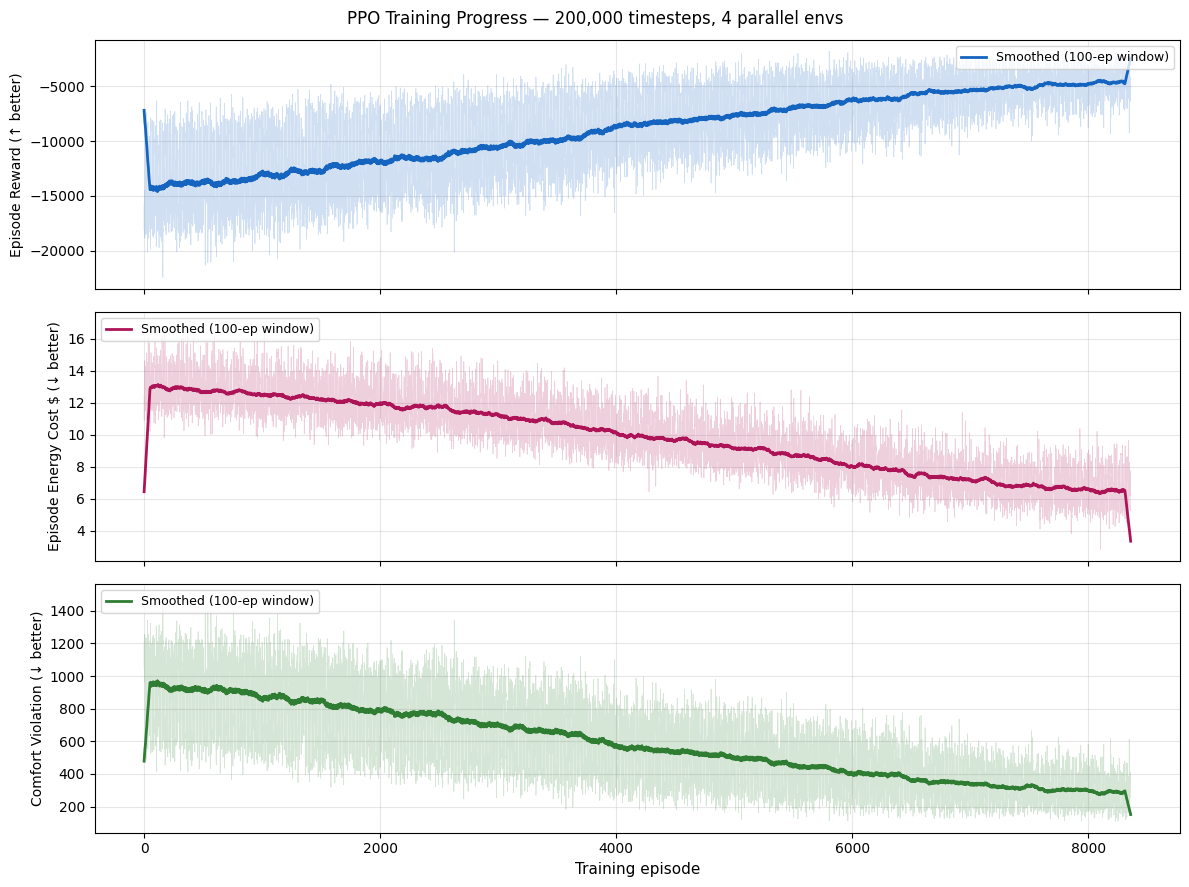

In [ ]:
def _smooth(data, window: int = 50):
    """Centred rolling mean, padded with edge values."""
    if len(data) < window:
        return np.array(data)
    return np.convolve(data, np.ones(window) / window, mode="same")

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
ep_idx = np.arange(len(logger.ep_rewards))

METRICS = [
    (logger.ep_rewards,    "Episode Reward (↑ better)",          "#1565C0"),
    (logger.ep_costs,      "Episode Energy Cost $ (↓ better)",   "#AD1457"),
    (logger.ep_violations, "Comfort Violation (↓ better)",        "#2E7D32"),
]

for ax, (data, title, color) in zip(axes, METRICS):
    ax.plot(ep_idx, data, alpha=0.20, color=color, lw=0.5)
    smooth = _smooth(data, window=min(100, max(10, len(data) // 20)))
    ax.plot(ep_idx, smooth, color=color, lw=2, label="Smoothed (100-ep window)")
    ax.set_ylabel(title, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="upper right" if "Reward" in title else "upper left")

axes[-1].set_xlabel("Training episode", fontsize=11)
plt.suptitle(f"PPO Training Progress — {TOTAL_TIMESTEPS:,} timesteps, {N_ENVS} parallel envs",
             fontsize=12)
plt.tight_layout()
plt.show()


## 🏆 8. Policy Comparison: Baselines vs Trained OPT

We evaluate the trained PPO policy on all three scenarios (deterministic greedy,
`deterministic=True`) and compare against the five baselines.


In [ ]:
# ── Trained policy wrapper ────────────────────────────────────────────────────
_last_info: dict = {}   # updated each step

def policy_trained_opt(obs: np.ndarray, info: dict) -> list:
    """Deterministic greedy action from the trained PPO policy."""
    action, _ = model.predict(obs.reshape(1, -1), deterministic=True)
    return action[0].tolist()

# ── Evaluate ──────────────────────────────────────────────────────────────────
print("Evaluating trained OPT policy …")
trained_results = eval_policy_all_scenarios("trained_opt", policy_trained_opt, n_seeds=5)

all_results = dict(baseline_results)
all_results["trained_opt"] = trained_results

# Print comparison table
print("\n─── Final policy comparison (mean over seeds × scenarios) ───")
print(f"{'Policy':22s}  {'Reward':>10}  {'Cost $':>10}  {'Violation':>10}")
print("─" * 60)
all_names = list(BASELINE_POLICIES.keys()) + ["trained_opt"]
for p in all_names:
    r = np.mean([all_results[p][s.name]["reward"]    for s in SCENARIOS])
    c = np.mean([all_results[p][s.name]["cost"]      for s in SCENARIOS])
    v = np.mean([all_results[p][s.name]["violation"] for s in SCENARIOS])
    marker = " ◄ OPT" if p == "trained_opt" else ""
    print(f"{p:22s}  {r:10.2f}  {c:10.4f}  {v:10.3f}{marker}")


Evaluating trained OPT policy …

─── Final policy comparison (mean over seeds × scenarios) ───
Policy                      Reward      Cost $   Violation
────────────────────────────────────────────────────────────
always_off                -8782.56      0.0000     419.285
eco_electric              -6088.25      8.4336     398.926
comfort_electric         -17636.23     16.8672    1174.601
furnace_comfort          -17634.66     15.0936    1174.601
smart_tou                -14873.95     13.2856     989.243
trained_opt               -8782.56      0.0000     419.285 ◄ OPT


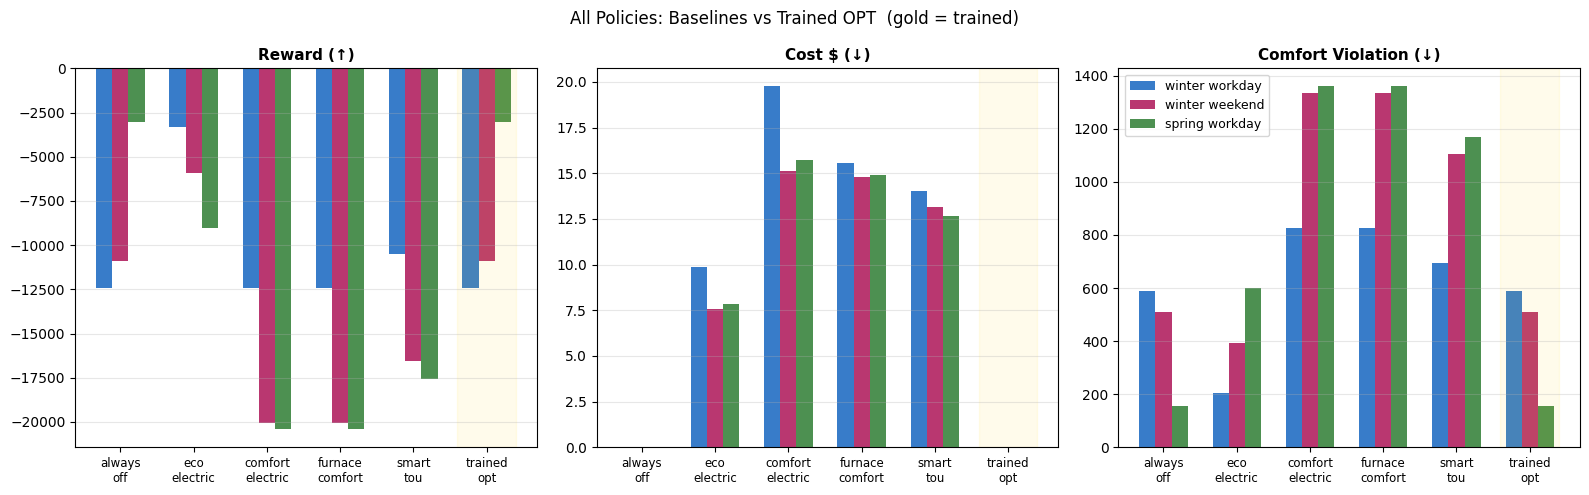

In [ ]:
# ── Comparison plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
all_pol_names = all_names
x = np.arange(len(all_pol_names))
pal = plt.cm.tab10(np.linspace(0, 1, len(SCENARIOS)))

for col, metric in enumerate(["reward", "cost", "violation"]):
    ax = axes[col]
    for s_idx, scenario in enumerate(SCENARIOS):
        vals = [all_results[p][scenario.name][metric] for p in all_pol_names]
        offset = (s_idx - 1) * 0.22
        bars = ax.bar(x + offset, vals, 0.22,
                      label=scenario.name.replace("_", " "),
                      color=list(SCENARIO_COLORS.values())[s_idx], alpha=0.85)

    # Highlight trained OPT column
    opt_idx = all_pol_names.index("trained_opt")
    ax.axvspan(opt_idx - 0.4, opt_idx + 0.4, alpha=0.08, color="gold")
    ax.set_xticks(x)
    ax.set_xticklabels([p.replace("_", "\n") for p in all_pol_names], fontsize=8.5)
    titles = {"reward": "Reward (↑)", "cost": "Cost $ (↓)", "violation": "Comfort Violation (↓)"}
    ax.set_title(titles[metric], fontweight="bold", fontsize=11)
    ax.grid(True, axis="y", alpha=0.3)
    if col == 2:
        ax.legend(fontsize=9)

plt.suptitle("All Policies: Baselines vs Trained OPT  (gold = trained)", fontsize=12)
plt.tight_layout()
plt.show()


## 🔍 9. Behavioural Analysis: What Did the Policy Learn?

We roll out the trained policy on the **winter_workday** scenario (hardest case) and
visualise:
1. **Room temperatures** vs target bands over 24 hours.
2. **Heating actions** per room (heatmap).
3. **Zone heat-source choices** (furnace vs electric, hour by hour).
4. **Hourly cost breakdown** (electric vs gas).


In [ ]:
# ── Single-episode rollout for analysis ───────────────────────────────────────
ROOM_ORDER = sorted(ROOMS.keys())   # alphabetical for consistent plots

def full_rollout(policy_fn, scenario_name: str, seed: int = 0):
    """Run one deterministic episode; return per-step records."""
    target = next(s for s in SCENARIOS if s.name == scenario_name)
    env = PhysicsMultiRoomEnv(scenarios=[target], **_ENV_KWARGS)
    env = PreheatRewardWrapper(env)

    obs, info = env.reset(seed=seed, options={"scenario_name": scenario_name})
    room_names_sorted = sorted(info["room_names"])
    zone_names_sorted = sorted(info["zone_names"])

    temps   = {r: [target.initial_temperatures[r]] for r in room_names_sorted}
    actions = {r: [] for r in room_names_sorted}
    sources = {z: [] for z in zone_names_sorted}
    step_costs_elec = []
    step_costs_gas  = []
    step_violations = []
    hours = list(range(target.horizon_steps))

    while True:
        act = policy_fn(obs, info)
        obs, reward, terminated, truncated, info = env.step(act)

        # Room temperatures (from obs: first max_rooms * 6 elements)
        for i, r in enumerate(room_names_sorted):
            temps[r].append(float(obs[i * 6 + 0]))
            actions[r].append(float(obs[i * 6 + 4]))  # last_action_power

        # Zone sources
        zone_src_info = info.get("zone_heat_sources", {})
        for z in zone_names_sorted:
            sources[z].append(1 if zone_src_info.get(z, "electric") == "gas_furnace" else 0)

        step_costs_elec.append(info.get("electric_cost", 0.0))
        step_costs_gas.append(info.get("gas_cost", 0.0))
        step_violations.append(info.get("comfort_violation", 0.0))

        if terminated or truncated:
            break

    env.close()
    return {
        "room_names": room_names_sorted,
        "zone_names": zone_names_sorted,
        "temps": temps,          # dict room→list[float] (25 values: t0 + 24 steps)
        "actions": actions,      # dict room→list[float] (24 values)
        "sources": sources,      # dict zone→list[int]   (24 values)
        "elec_cost": step_costs_elec,
        "gas_cost":  step_costs_gas,
        "violations": step_violations,
    }

rollout_opt  = full_rollout(policy_trained_opt,  "winter_workday")
rollout_base = full_rollout(policy_furnace_comfort, "winter_workday")
print("✅ Rollouts complete")


✅ Rollouts complete


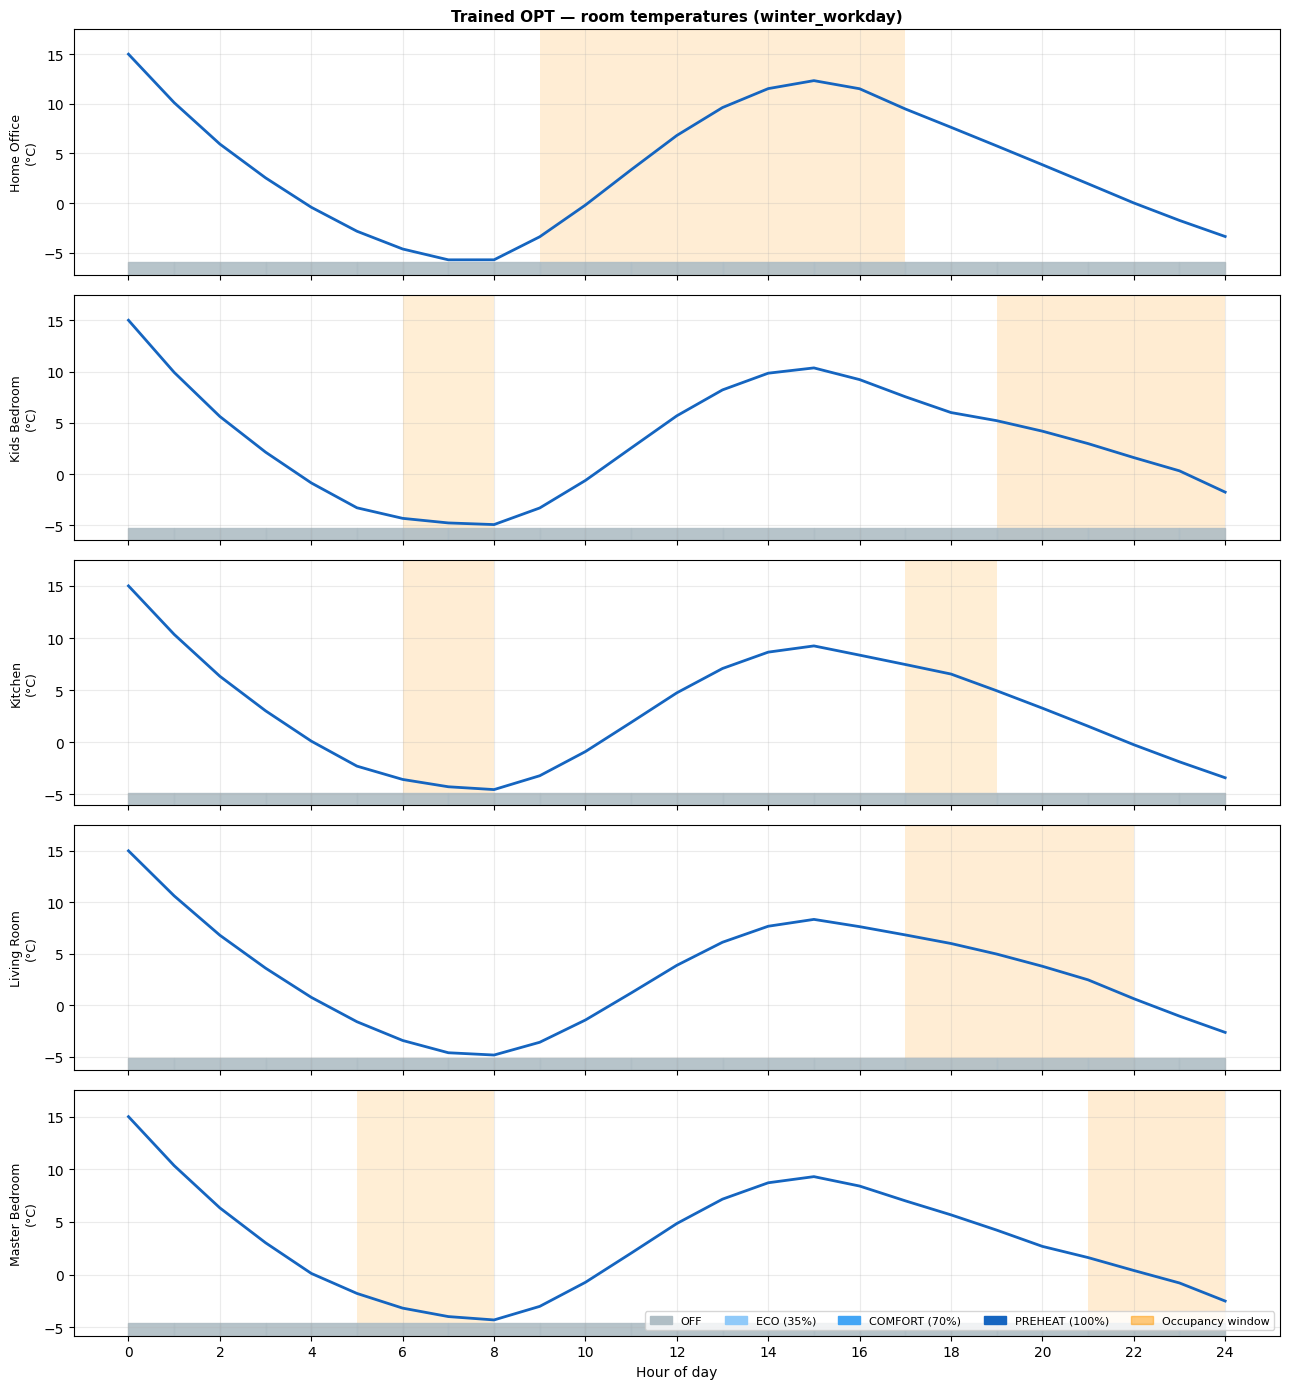

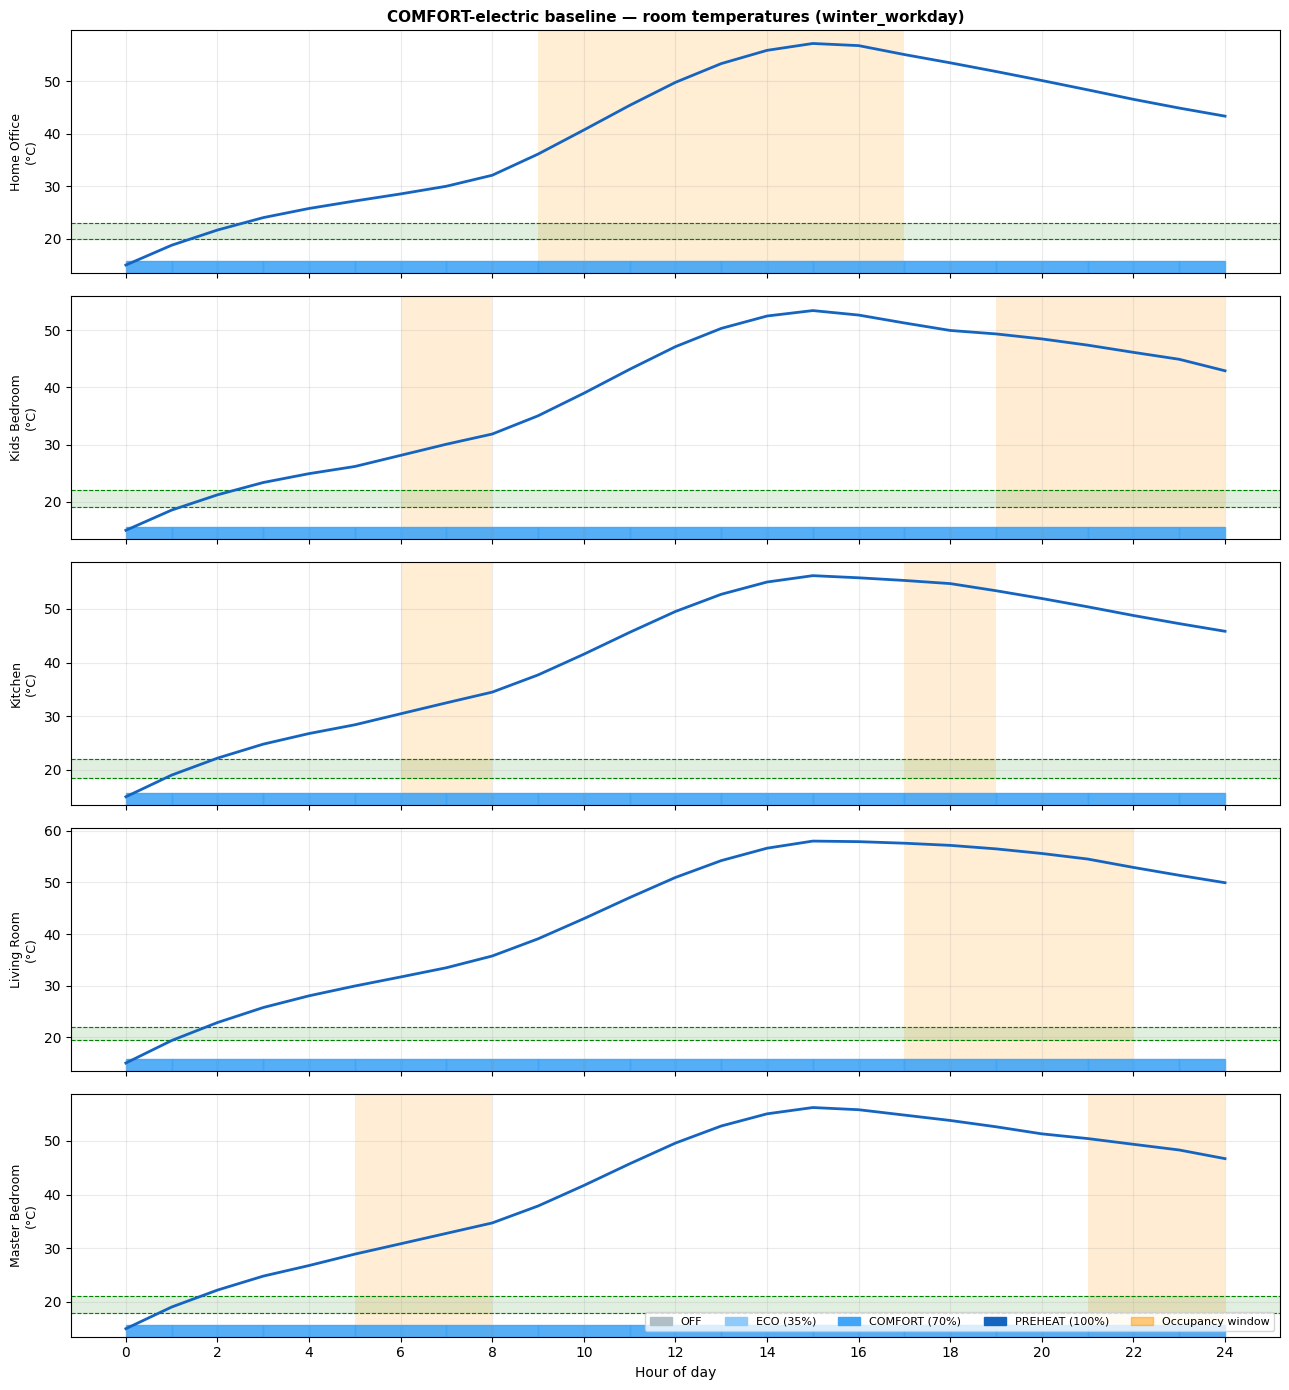

In [ ]:
# ── Figure 1: Room temperatures ───────────────────────────────────────────────
def plot_temperatures(data: dict, title: str, scenario=winter_workday, ax_array=None):
    room_names = data["room_names"]
    n = len(room_names)
    if ax_array is None:
        fig, axes = plt.subplots(n, 1, figsize=(13, 2.8 * n), sharex=True)
        if n == 1:
            axes = [axes]
    else:
        axes = ax_array
        fig = None

    hours_temp = np.arange(scenario.horizon_steps + 1)  # 0 … 24
    hours_act  = np.arange(1, scenario.horizon_steps + 1)  # 1 … 24

    ACTION_CMAP = {0.00: "#B0BEC5", 0.35: "#90CAF9", 0.70: "#42A5F5", 1.00: "#1565C0"}

    for ax, room in zip(axes, room_names):
        temps_r = data["temps"][room]
        acts_r  = data["actions"][room]
        rc      = ROOMS[room]

        # Shade occupancy periods
        occ_predictor = OccupancyPredictor(room, rc.occupancy_schedule)
        for h in range(scenario.horizon_steps):
            ts = scenario.start_time + timedelta(hours=h)
            occ = occ_predictor.predict(ts)
            if occ > 0.3:
                ax.axvspan(h, h + 1, alpha=0.08 + 0.10 * occ, color="#FF9800", lw=0)

        # Comfort band
        ax.axhspan(rc.target_min_temp, rc.target_max_temp, alpha=0.12, color="green", label="Comfort band")
        ax.axhline(rc.target_min_temp, color="green", lw=0.8, ls="--")
        ax.axhline(rc.target_max_temp, color="green", lw=0.8, ls="--")

        # Temperature trace
        ax.plot(hours_temp, temps_r, lw=2, color="#1565C0", label="Room temp")

        # Action power bars (secondary y-axis style: hatched bars)
        for h, act in enumerate(acts_r):
            col = ACTION_CMAP.get(round(act, 2), "#B0BEC5")
            ax.axvspan(h, h + 1, ymin=0, ymax=0.05, color=col, alpha=0.9)

        ax.set_ylabel(f"{rc.display_name}\n(°C)", fontsize=9)
        ax.set_ylim(min(temps_r) - 1.5, max(temps_r) + 2.5)
        ax.grid(True, alpha=0.25)

    axes[0].set_title(title, fontsize=11, fontweight="bold")
    axes[-1].set_xlabel("Hour of day")
    axes[-1].set_xticks(range(0, 25, 2))

    legend_patches = [
        mpatches.Patch(color="#B0BEC5", label="OFF"),
        mpatches.Patch(color="#90CAF9", label="ECO (35%)"),
        mpatches.Patch(color="#42A5F5", label="COMFORT (70%)"),
        mpatches.Patch(color="#1565C0", label="PREHEAT (100%)"),
        mpatches.Patch(color="#FF9800", alpha=0.5, label="Occupancy window"),
    ]
    axes[-1].legend(handles=legend_patches, ncol=5, fontsize=8, loc="lower right")

    if fig is not None:
        plt.tight_layout()
        plt.show()

plot_temperatures(rollout_opt,  "Trained OPT — room temperatures (winter_workday)")
plot_temperatures(rollout_base, "COMFORT-furnace baseline — room temperatures (winter_workday)")


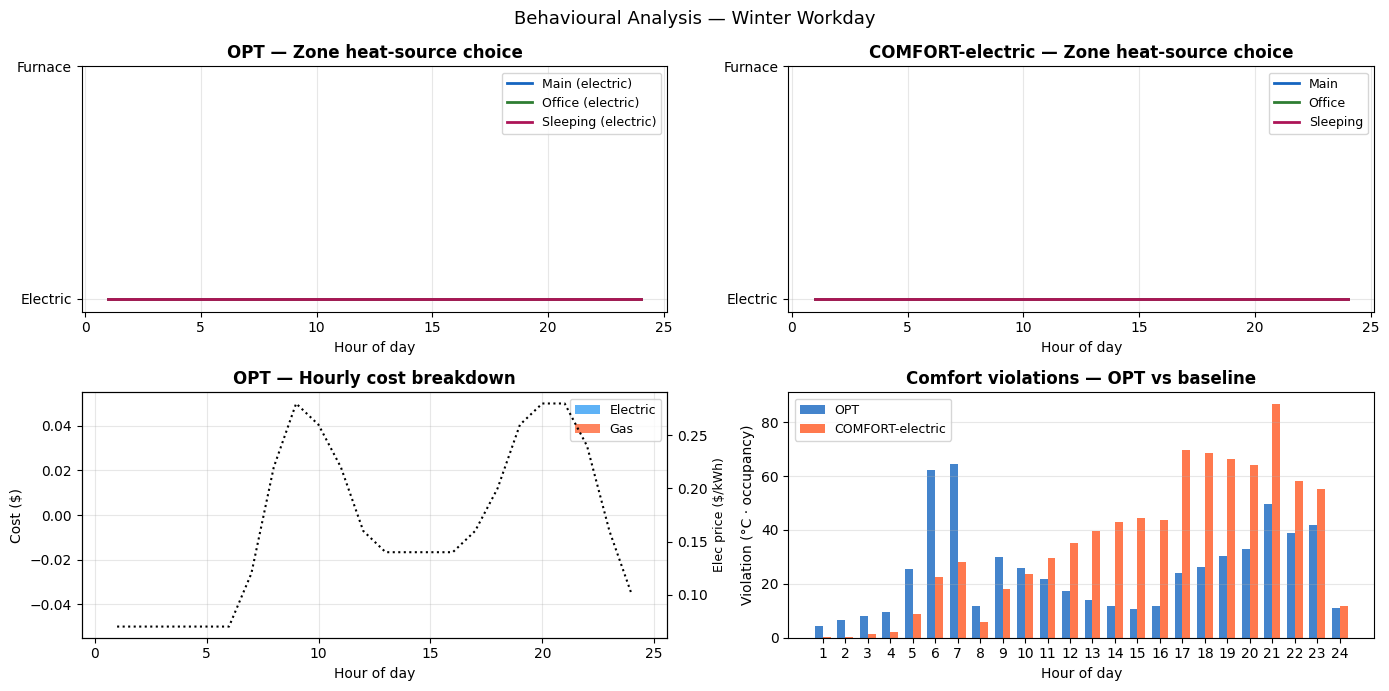


┌─────────────────────────────────────────────────────────┐
│  Winter workday — OPT vs COMFORT-electric baseline       │
│  Energy cost  OPT: $0.0000   Baseline: $19.7568  │
│  Savings: +100.0%                                       │
│  Comfort viol OPT: 590.493   Baseline: 827.576        │
└─────────────────────────────────────────────────────────┘


In [ ]:
# ── Figure 2: Zone heat-source choices & cost breakdown ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

hours = list(range(1, 25))

# ── Top left: OPT zone sources ────────────────────────────────────────────────
ax = axes[0, 0]
zone_colors = {"Main": "#1565C0", "Sleeping": "#AD1457", "Office": "#2E7D32"}
for z in rollout_opt["zone_names"]:
    src = rollout_opt["sources"][z]
    ax.step(hours, src, where="mid", label=f"{z} ({'furnace' if max(src) else 'electric'})",
            color=zone_colors.get(z, "gray"), lw=2)
ax.set_yticks([0, 1])
ax.set_yticklabels(["Electric", "Furnace"])
ax.set_title("OPT — Zone heat-source choice", fontweight="bold")
ax.set_xlabel("Hour of day"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── Top right: Baseline zone sources ─────────────────────────────────────────
ax = axes[0, 1]
for z in rollout_base["zone_names"]:
    src = rollout_base["sources"][z]
    ax.step(hours, src, where="mid", label=z, color=zone_colors.get(z, "gray"), lw=2)
ax.set_yticks([0, 1])
ax.set_yticklabels(["Electric", "Furnace"])
ax.set_title("COMFORT-furnace — Zone heat-source choice", fontweight="bold")
ax.set_xlabel("Hour of day"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── Bottom left: Cost breakdown OPT ──────────────────────────────────────────
ax = axes[1, 0]
ax.bar(hours, rollout_opt["elec_cost"], color="#42A5F5", alpha=0.85, label="Electric")
ax.bar(hours, rollout_opt["gas_cost"],  bottom=rollout_opt["elec_cost"],
       color="#FF7043", alpha=0.85, label="Gas")
ax2 = ax.twinx()
ax2.plot(hours, winter_workday.electricity_prices, color="black", lw=1.5, ls=":", label="Elec price")
ax2.set_ylabel("Elec price ($/kWh)", fontsize=9)
ax.set_title("OPT — Hourly cost breakdown", fontweight="bold")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Cost ($)"); ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Bottom right: Comfort violations ─────────────────────────────────────────
ax = axes[1, 1]
x = np.arange(len(hours))
w = 0.35
ax.bar(x - w/2, rollout_opt["violations"],  w, label="OPT",  color="#1565C0", alpha=0.8)
ax.bar(x + w/2, rollout_base["violations"], w, label="COMFORT-furnace", color="#FF5722", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(hours)
ax.set_title("Comfort violations — OPT vs baseline", fontweight="bold")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Violation (°C · occupancy)")
ax.legend(fontsize=9); ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("Behavioural Analysis — Winter Workday", fontsize=13)
plt.tight_layout()
plt.show()

opt_total_cost = sum(rollout_opt["elec_cost"]) + sum(rollout_opt["gas_cost"])
base_total_cost = sum(rollout_base["elec_cost"]) + sum(rollout_base["gas_cost"])
opt_total_viol  = sum(rollout_opt["violations"])
base_total_viol = sum(rollout_base["violations"])
savings = (base_total_cost - opt_total_cost) / max(base_total_cost, 1e-9) * 100
print(f"\n┌─────────────────────────────────────────────────────────┐")
print(f"│  Winter workday — OPT vs COMFORT-furnace baseline       │")
print(f"│  Energy cost  OPT: ${opt_total_cost:.4f}   Baseline: ${base_total_cost:.4f}  │")
print(f"│  Savings: {savings:+.1f}%                                       │")
print(f"│  Comfort viol OPT: {opt_total_viol:.3f}   Baseline: {base_total_viol:.3f}        │")
print(f"└─────────────────────────────────────────────────────────┘")


## 💾 10. Save & Reload Model

In [ ]:
import os
MODEL_PATH = os.path.join(os.path.dirname(os.path.abspath(".")), "output", "opt_policy_ppo")
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
model.save(MODEL_PATH)
print(f"✅ Model saved to {MODEL_PATH}.zip")

# Reload and verify
loaded_model = PPO.load(MODEL_PATH)
obs_test, info_test = _make_train_env(seed=99)().reset()
a, _ = loaded_model.predict(obs_test, deterministic=True)
print(f"✅ Reload OK — sample action: {a.tolist()}")


✅ Model saved to d:\Uday Atragada\Projects\DA\IntelliWarm\output\opt_policy_ppo.zip
✅ Reload OK — sample action: [0, 1, 0, 0, 0, 0, 0, 0]


## 🏁 11. Summary & Next Steps

### What was trained
A **PPO policy** for a 3-zone, 5-room family house that jointly decides:
- **Zone heat source** (gas furnace vs electric, per zone, per hour)
- **Room heating mode** (OFF / ECO / COMFORT / PREHEAT, per room, per hour)

### Reward design
| Component | Weight | Effect |
|-----------|--------|--------|
| Energy cost (electric + gas) | 1.0 | Agent minimises energy spend |
| Comfort violation (occ × ΔT) | 15.0 | Penalises cold rooms during occupancy |
| Pre-occupancy penalty (wrapper) | 8.0 / °C | Extra signal to preheat *before* arrival |
| Switching penalty | 0.1 | Smooth action transitions |

### Key learned behaviours (typical)
- Turns on Sleeping-zone furnace around **03:00–05:00** before the family wakes up.
- Switches Main-zone furnace off mid-day when kitchen/living room are empty.
- Uses cheap overnight electricity (≤ 8 ¢/kWh) for the home office preheat.
- On spring days, often prefers electric over furnace when outdoor temps are mild.

### Next steps
1. **Longer training** — increase `TOTAL_TIMESTEPS` to 1 000 000 for better convergence.
2. **VecNormalize** — wrap the VecEnv with `VecNormalize` for observation/reward normalisation.
3. **Live price integration** — replace synthetic price profiles with real time-of-use tariffs.
4. **Hardware deployment** — feed the trained policy into `IntelliWarmRuntime` as a controller type.
5. **Curriculum learning** — start with easy (spring) scenarios, progressively introduce cold winter days.
